In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
import joblib

from gplearn.genetic import SymbolicClassifier

import torch
import torch.nn as nn

sns.set_style("ticks")

In [2]:
# Data
from src.debbirth.data.schema import DatasetSpec
from src.debbirth.data.load import load_data_gp, load_data_pytorch
# GP
from src.debbirth.models.gp.train import load_gp_run
# NN
from src.debbirth.models.nn.train import load_trained_nn
# Plotting
from src.debbirth.plot.boundary import plot_decision_mesh, plot_decision_mesh_with_models
# Utils
from src.debbirth.utils.results import *

# Setup

In [3]:
cdir = Path().cwd()

save_figure_dir = Path(
    r"C:\Users\diogo\OneDrive - Universidade de Lisboa\Conferences\2026\World Conference on Computational Intelligence\figures")

best_models_dir = cdir.parent / "results" / "models"

simul_data_dir = cdir.parent / "data" / "raw"

# Load models

## Load Genetic Programming model

In [4]:
gp_model_path = best_models_dir / "DEBBirthGP"
# gp_model_path = best_models_dir.parent / "runs" / "2026-01-29T14-30-10_DEBBirthSymbolicClassifier"
loaded_gp = load_gp_run(gp_model_path)

In [5]:
gp = loaded_gp["model"]
gp_train_cfg = loaded_gp["train_cfg"]

## Load Neural Network model

In [6]:
nn_model_path = best_models_dir / "DEBBirthNet"
loaded_nn = load_trained_nn(nn_model_path)

In [7]:
net = loaded_nn["model"]
scaler = loaded_nn["scaler"]
nn_train_cfg = loaded_nn["train_cfg"]

# Load simulation data

In [8]:
# simul_filename = "grid_g_1em5_1e2_Ng_300_vHb_1em6_1e1_Nv_300_k_0p3_f_0p8_getlb2.csv"
# simul_filename = "grid_g_1em5_1e2_Ng_300_vHb_1em6_1e1_Nv_300_k_3_f_0p8_getlb2.csv"
# simul_filename = "grid_g_1em5_1e2_Ng_300_vHb_1em6_1e1_Nv_300_k_30_f_0p8_getlb2.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_0p01_100_N300_f_fixed_1.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_0p01_100_N300_f_fixed_0p3.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_3_vHb_log_0p0001_0p1_N300_f_fixed_0p3.csv"
simul_filename = "grid_g_log_0p001_100_N300_k_fixed_1_vHb_log_0p001_10_N300_f_fixed_0p8.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_0p0001_1_N300_f_fixed_0p3.csv"

simul_data_path = simul_data_dir / simul_filename

df = pd.read_csv(simul_data_path, index_col=0)
df['reached_birth'] = df['reached_birth'].astype(bool)
df['lb<f'] = df['lb<f'].astype(bool)
df['k*vHb<c'] = df['k*vHb<c'].astype(bool)

df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
Row,,,,,,,,,,,,,
1,0.001000,1,0.001,0.8,0.100000,307.777240,True,True,True,1,0.297413,none,NaN
2,0.001039,1,0.001,0.8,0.100000,296.155412,True,True,True,1,0.280838,none,NaN
3,0.001080,1,0.001,0.8,0.100000,284.972557,True,True,True,1,0.274328,none,NaN
4,0.001122,1,0.001,0.8,0.100000,274.212094,True,True,True,1,0.272239,none,NaN
5,0.001167,1,0.001,0.8,0.100000,263.858067,True,True,True,1,0.259269,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89996,85.725567,1,10.000,0.8,2.154435,0.186898,False,False,False,1,1.627054,none,NaN
89997,89.090783,1,10.000,0.8,2.154435,0.180635,False,False,False,1,1.628541,none,NaN
89998,92.588103,1,10.000,0.8,2.154435,0.174581,False,False,False,1,1.629906,none,NaN


In [9]:
k = df.iloc[0]['k']
f = df.iloc[0]['f']

k_fmt = "{:.1f}".format(k).replace(".", "p")
f_fmt = "{:.1f}".format(f).replace(".", "p")

# Plot decision boundaries

## Simulation data

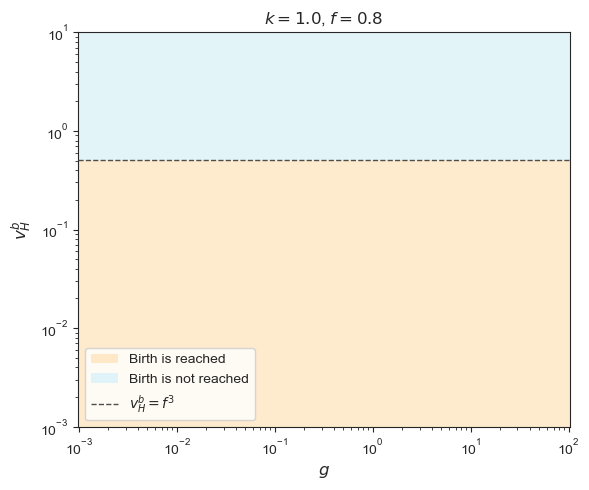

In [10]:
fig, ax = plot_decision_mesh(df=df, decision_col='reached_birth')

## Plot GP decision boundary

In [11]:
X = np.array([df['g'], df['k'], df['v_Hb'], df['f']]).T
gp_preds = gp.predict(X)
df['gp_pred'] = gp_preds

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': '$k=1.0$, $f=0.8$'}, xlabel='$g$', ylabel='$v_H^b$'>)

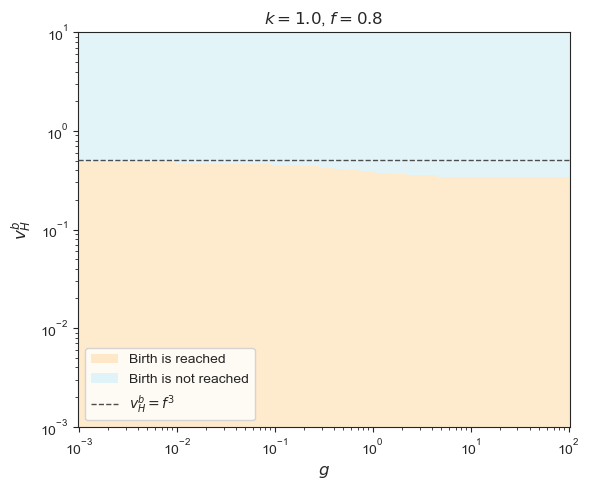

In [12]:
plot_decision_mesh(df=df, decision_col='gp_pred')

# Plot NN decision boundary

In [13]:
X = torch.tensor(np.array([df['g'], df['k'], df['v_Hb'], df['f']]).T, dtype=torch.float32)
X_scaled = scaler.transform(X)
net.eval()
df['nn_pred'] = net.predict(X_scaled)

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': '$k=1.0$, $f=0.8$'}, xlabel='$g$', ylabel='$v_H^b$'>)

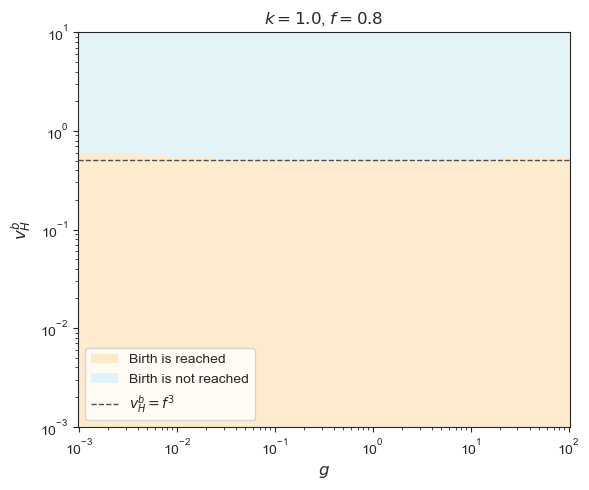

In [14]:
plot_decision_mesh(df=df, decision_col='nn_pred')

## Compare boundaries with simulation data

Text(0, 0.5, 'Scaled maturity at birth ($v_H^b$)')

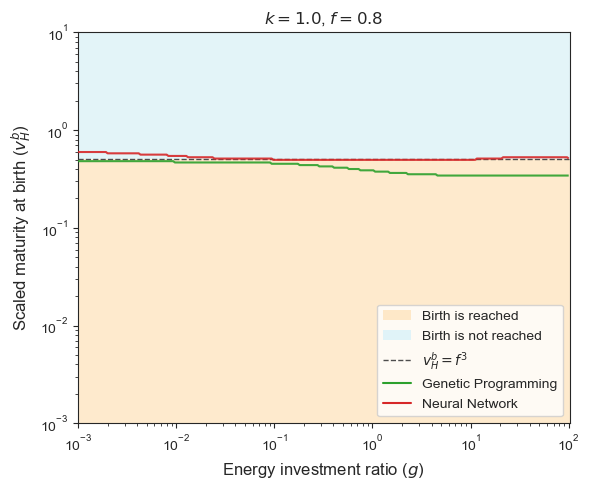

In [15]:
fig, ax = plot_decision_mesh_with_models(df=df, model_cols=['gp_pred', 'nn_pred'], decision_col='reached_birth', model_labels=['Genetic Programming', 'Neural Network'], model_colors=['tab:green', 'tab:red'], linewidth=1.5,
                                         legend_loc='lower right')

ax.set_xlabel(f"Energy investment ratio ($g$)")
ax.set_ylabel(f"Scaled maturity at birth ($v_H^b$)")
#ax.legend(loc='lower right')

In [16]:
save_figure_in_formats(fig, outdir=save_figure_dir, filename=f"boundary_compare_k_{k_fmt}_f_{f_fmt}", dpi=300, formats=['png', 'pdf'])

In [17]:
f = 0.3
k = 0.3
if k > 1:
    lower_bound = f ** 3 / k ** 3 / 10
    upper_bound = f ** 3 / k * 10
    print(f"{lower_bound:.3e} < v_Hb < {upper_bound:.3e}")
elif k < 1:
    lower_bound = f ** 3 / 10
    upper_bound = f ** 3 / k * 10
    print(f"{lower_bound:.3e} < v_Hb < {upper_bound:.3e}")


2.700e-03 < v_Hb < 9.000e-01
